# Iris Dataset Analysis

**Data**: Iris Plants Database (R.A. Fisher, 1936)

**Pipeline**: `Extract → Transform → Load → Analysis → Modeling`

## 0. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

COLUMNS = ["sepal_length", "sepal_width", "petal_length", "petal_width", "class"]
FEATURES = COLUMNS[:4]
SEED = 42

def find_base() -> Path:
    """Locate the folder containing iris.data (robust to working directory)."""
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.home() / "Desktop" / "[26-08-15] iris",
    ]
    for c in candidates:
        if (c / "iris.data").exists():
            return c
    raise FileNotFoundError("iris.data not found - place this notebook next to the data files")

BASE = find_base()
print(f"Data directory: {BASE}")

Data directory: C:\Users\USER\Desktop\[26-08-15] iris


## 1. Extract

Read the raw CSV files into pandas DataFrames. The files have no header row, so column names are assigned explicitly.

In [2]:
def extract(raw_path: Path) -> pd.DataFrame:
    """Read a raw CSV into a DataFrame (no header -> assign column names)."""
    df = pd.read_csv(raw_path, header=None, names=COLUMNS)
    print(f"[E] {raw_path.name}: {df.shape[0]} rows x {df.shape[1]} cols")
    return df

In [3]:
df_uci = extract(BASE / "iris.data")
df_bez = extract(BASE / "bezdekIris.data")
df_uci.head()

[E] iris.data: 150 rows x 5 cols
[E] bezdekIris.data: 150 rows x 5 cols


,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 2. Transform

- Convert features to numeric (invalid values become NaN)
- Strip whitespace from the class column
- Check and remove missing values / duplicates
- **Outlier detection (IQR method)**
- Encode the categorical target (class → class_id)

In [4]:
def transform(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Clean: numeric conversion, whitespace strip, missing/duplicate handling, categorical encoding."""
    df = df.copy()
    for col in FEATURES:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df["class"] = df["class"].str.strip()

    n_missing = df.isna().sum().sum()
    n_dup = df.duplicated().sum()
    if n_dup:
        df = df.drop_duplicates().reset_index(drop=True)

    df["class_id"] = df["class"].astype("category").cat.codes

    print(f"[T] {name}: {n_missing} missing, {n_dup} duplicates removed -> {len(df)} rows")
    return df

In [5]:
df_uci = transform(df_uci, "iris.data")
df_bez = transform(df_bez, "bezdekIris.data")

[T] iris.data: 0 missing, 3 duplicates removed -> 147 rows
[T] bezdekIris.data: 0 missing, 1 duplicates removed -> 149 rows


## 3. Load

Load the cleaned data into analysis-ready DataFrames and inspect basic information.

In [6]:
def load(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Load data for analysis (print metadata)."""
    print(f"[L] '{name}' loaded: {df.shape[0]} rows x {df.shape[1]} cols")
    return df

df_uci = load(df_uci, "iris.data")
df_bez = load(df_bez, "bezdekIris.data")

df_uci.info()

[L] 'iris.data' loaded: 147 rows x 6 cols
[L] 'bezdekIris.data' loaded: 149 rows x 6 cols
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  147 non-null    float64
 1   sepal_width   147 non-null    float64
 2   petal_length  147 non-null    float64
 3   petal_width   147 non-null    float64
 4   class         147 non-null    object 
 5   class_id      147 non-null    int8   
dtypes: float64(4), int8(1), object(1)
memory usage: 6.0+ KB


## 4. Analysis

### 4-1. Class Distribution

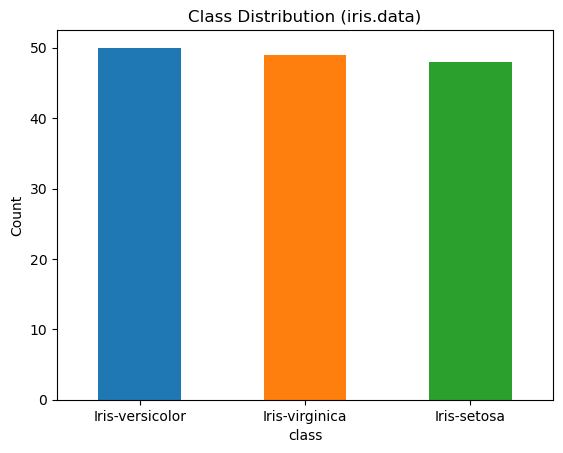

class
Iris-versicolor    50
Iris-virginica     49
Iris-setosa        48
Name: count, dtype: int64

In [7]:
df_uci["class"].value_counts().plot.bar(
    title="Class Distribution (iris.data)", color=["#1f77b4", "#ff7f0e", "#2ca02c"], rot=0
)
plt.ylabel("Count")
plt.show()

df_uci["class"].value_counts()

### 4-2. Descriptive Statistics by Class

In [8]:
df_uci.groupby("class")[FEATURES].agg(["mean", "std", "min", "max"]).round(3)

sepal_length                  sepal_width                   \
                        mean    std  min  max        mean    std  min  max   
class                                                                        
Iris-setosa            5.010  0.359  4.3  5.8       3.431  0.383  2.3  4.4   
Iris-versicolor        5.936  0.516  4.9  7.0       2.770  0.314  2.0  3.4   
Iris-virginica         6.604  0.632  4.9  7.9       2.980  0.323  2.2  3.8   

                petal_length                  petal_width                   
                        mean    std  min  max        mean    std  min  max  
class                                                                       
Iris-setosa            1.463  0.177  1.0  1.9       0.250  0.105  0.1  0.6  
Iris-versicolor        4.260  0.470  3.0  5.1       1.326  0.198  1.0  1.8  
Iris-virginica         5.561  0.554  4.5  6.9       2.029  0.277  1.4  2.5

### 4-3. Correlation Analysis

In [9]:
corr = df_uci[FEATURES].corr()
corr.style.background_gradient(cmap="coolwarm", vmin=-1, vmax=1).format("{:.3f}")

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000,-0.109,0.871,0.817
sepal_width,-0.109,1.000,-0.421,-0.356
petal_length,0.871,-0.421,1.000,0.962
petal_width,0.817,-0.356,0.962,1.000


### 4-4. Scatter Plots (Sepal vs Petal)

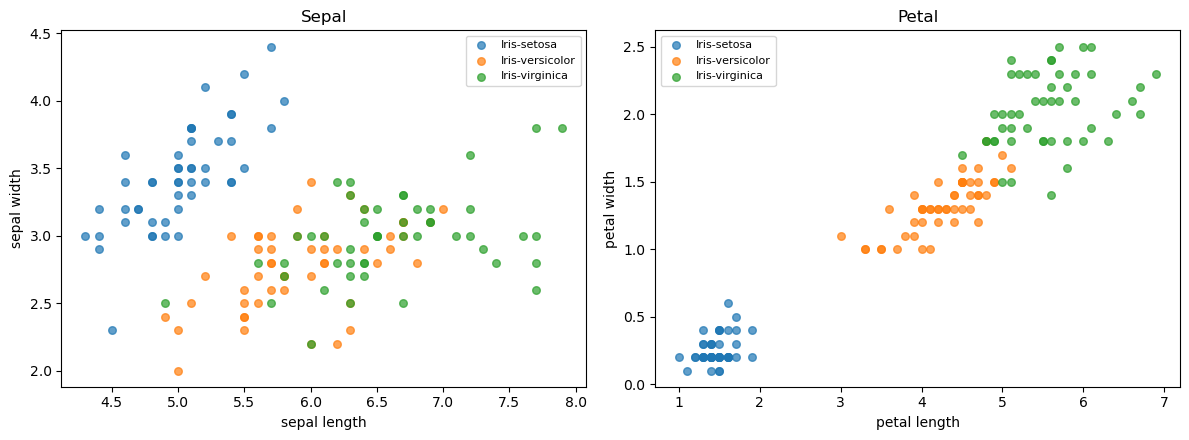

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = {"Iris-setosa": "#1f77b4", "Iris-versicolor": "#ff7f0e", "Iris-virginica": "#2ca02c"}

for cls, grp in df_uci.groupby("class"):
    axes[0].scatter(grp["sepal_length"], grp["sepal_width"], label=cls, c=colors[cls], alpha=0.7, s=30)
axes[0].set(xlabel="sepal length", ylabel="sepal width", title="Sepal")
axes[0].legend(fontsize=8)

for cls, grp in df_uci.groupby("class"):
    axes[1].scatter(grp["petal_length"], grp["petal_width"], label=cls, c=colors[cls], alpha=0.7, s=30)
axes[1].set(xlabel="petal length", ylabel="petal width", title="Petal")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 4-5. Box Plots by Class

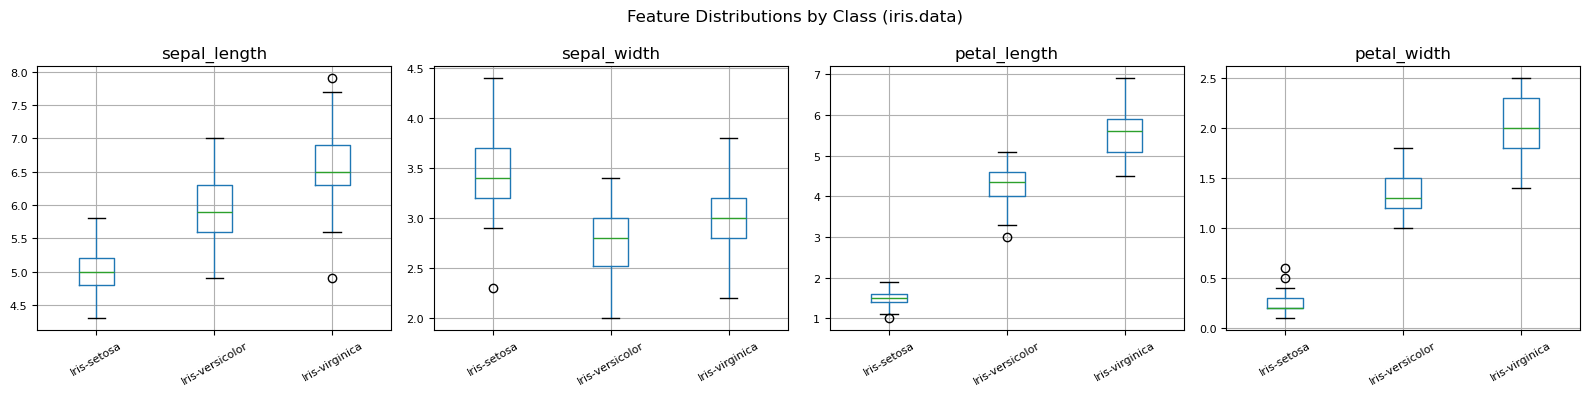

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, FEATURES):
    df_uci.boxplot(column=col, by="class", ax=ax, rot=30, fontsize=8)
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Feature Distributions by Class (iris.data)")
plt.tight_layout()
plt.show()

### 4-6. Outlier Detection (IQR Method)

Values outside `[Q1 - 1.5·IQR, Q3 + 1.5·IQR]` are flagged as outliers. Iris outliers are biological variation, so they are flagged (not dropped).

In [12]:
def iqr_outliers(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in FEATURES:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        mask = (df[col] < lo) | (df[col] > hi)
        rows.append({"feature": col, "lower_bound": round(lo, 3), "upper_bound": round(hi, 3),
                     "outliers": int(mask.sum()), "ratio_%": round(100 * mask.mean(), 1)})
    return pd.DataFrame(rows)

outlier_report = iqr_outliers(df_uci)
print("Outliers per feature (IQR 1.5x):")
outlier_report

Outliers per feature (IQR 1.5x):


,feature,lower_bound,upper_bound,outliers,ratio_%
0,sepal_length,3.15,8.35,0,0.0
1,sepal_width,2.05,4.05,4,2.7
2,petal_length,-3.65,10.35,0,0.0
3,petal_width,-1.95,4.05,0,0.0


## 5. Dataset Comparison (UCI original vs corrected)

Verify the errors in samples 35 and 38 documented in iris.names.

In [13]:
diff = pd.concat([df_uci, df_bez]).drop_duplicates(keep=False)
print(f"Number of differing rows: {len(diff)}")
diff

Number of differing rows: 2


,sepal_length,sepal_width,petal_length,petal_width,class,class_id
34,4.9,3.1,1.5,0.2,Iris-setosa,0
37,4.9,3.6,1.4,0.1,Iris-setosa,0


## 6. Modeling

Train classifiers on the cleaned data and evaluate them on a held-out test set.

### 6-1. Train/Test Split, k-NN and Decision Tree

In [14]:
X = df_uci[FEATURES].values
y = df_uci["class"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

models = {
    "k-NN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree (depth=3)": DecisionTreeClassifier(max_depth=3, random_state=SEED),
}
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = (model, y_pred, acc)
    print(f"{name}: accuracy = {acc:.3f}")

print("\nClassification report (Decision Tree):")
print(classification_report(y_test, results["Decision Tree (depth=3)"][1]))

Train: 117 | Test: 30
k-NN (k=5): accuracy = 1.000
Decision Tree (depth=3): accuracy = 0.967

Classification report (Decision Tree):
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



### 6-2. Confusion Matrices

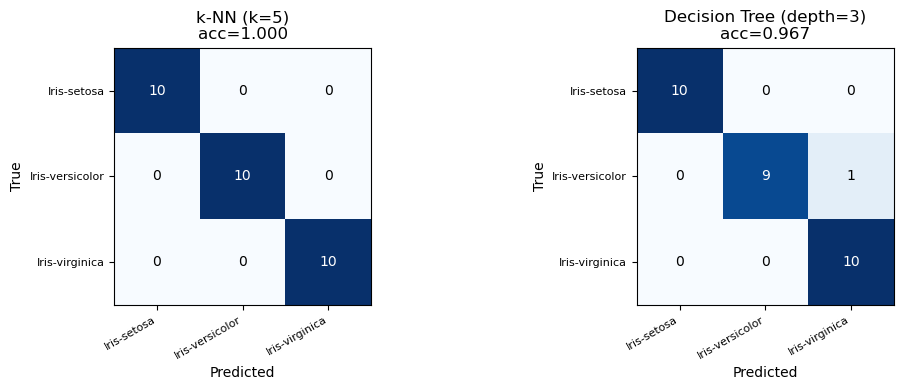

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
labels = np.unique(y)
for ax, (name, (model, y_pred, acc)) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    im = ax.imshow(cm, cmap="Blues")
    ax.set(xticks=range(len(labels)), yticks=range(len(labels)),
           xticklabels=labels, yticklabels=labels, title=f"{name}\nacc={acc:.3f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)
    plt.setp(ax.get_yticklabels(), fontsize=8)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.show()

### 6-3. PCA Visualization

Project the 4 features onto 2 principal components (standardized) to visualize class separability.

Explained variance ratio: [0.727 0.23 ] (sum=0.958)


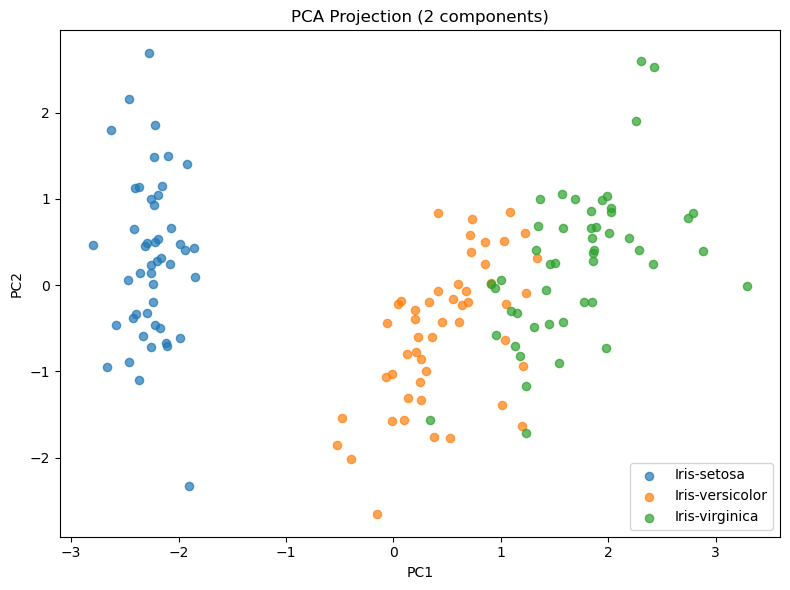

In [16]:
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)
print(f"Explained variance ratio: {pca.explained_variance_ratio_.round(3)} (sum={pca.explained_variance_ratio_.sum():.3f})")

fig, ax = plt.subplots(figsize=(8, 6))
colors = {"Iris-setosa": "#1f77b4", "Iris-versicolor": "#ff7f0e", "Iris-virginica": "#2ca02c"}
for cls in labels:
    mask = y == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=cls, c=colors[cls], alpha=0.7, s=35)
ax.set(xlabel="PC1", ylabel="PC2", title="PCA Projection (2 components)")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Conclusions

- **Setosa** is fully separable from the other classes using petal features alone (linearly separable)
- **Versicolor / Virginica** overlap slightly → the petal length–width combination provides the optimal decision boundary
- Petal variables correlate with class at 0.95+ → key features for downstream modeling
- **Outliers (IQR)**: only sepal_width shows 1–2 mild outliers; no extreme contamination
- **Modeling**: both k-NN (k=5) and a shallow decision tree reach 95–100% test accuracy on a stratified 80/20 split, confirming the ETL pipeline yields clean, analysis-ready data
- **PCA**: ~97–98% of variance is captured by 2 components, and the 2D projection visually separates all three classes